# IrriGator — Full End-to-End Pipeline

Central notebook covering **every block** from raw data to irrigation recommendation.

| Block | What | Data source | Run frequency |
|-------|------|-------------|---------------|
| 0 | Data ingestion | ERA5-Land (France-wide), COMEPHORE, Sentinel-2, soil, DEM | Once (historical archive) |
| 1 | Static layers | EU-SoilHydroGrids, IGN DEM | Once per parcel |
| 2 | Atmospheric forcing | ERA5-Land daily → parcel extraction | Once (cache), then per parcel |
| 3+4 | Simulation | Water balance + crop growth ACQUACROP | Daily |
| 5a | Short-term forecast | AROME (0-48h) + IFS ENS (0-15d) → ensemble | Daily |
| 5b | Seasonal outlook | SEAS5 → PCA analog → ensemble water balance | Monthly |
| 6 | Decision | Ensemble stress → irrigation recommendation | Daily |

**Architecture change:** ERA5-Land is now downloaded once for all of metropolitan
France (41°N–51.5°N, 6°W–10°E). Any new parcel is served from this cache
without additional API calls. AROME and IFS ENS already work the same way.

---
## Configuration — set your "today" and paths here

In [1]:
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

#TODAY = date(2025, 12, 31)          # the date we treat as "today"
TODAY = date.today()
SIMULATION_START = date(2026, 1, 1) # start of the growing season simulation
LAST_IRRIGATION = None              # date of last irrigation, or None for rainfed
RUN_SEAS5 = False                   # set True to include seasonal outlook (slow)
SHIFT = 0                           # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")                # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")     # daily aggregates, cached results

# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = "configs/parcels/example.yaml"
CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

Repo root: /home/mbaldacchino/code/IrriGator
Today:     2026-07-03
Raw dir:   data/raw
Processed: data/processed


---
## Block 0 — Data Ingestion

Run these cells **once** to download and cache the historical archive.
Skip if data is already on disk.

ERA5-Land is downloaded for all of France — not per region. One download
covers any parcel in metropolitan France.

In [2]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)

print(f"Region: {cfg.name} (dept {cfg.code_departement})")
print(f"Parcel: {parcel.name} ({parcel.id})")
print(f"Crop:   {parcel.crop.get('type')} — planting {parcel.crop.get('planting_date')}")

Region: Dordogne (dept 24)
Parcel: Parcelle Les Graves (24_bergerac_001)
Crop:   grain_maize — planting 2026-04-20


In [3]:
# --- ERA5-Land download (skip if already done) ---
# France-wide, no per-region dependency
from irrigator.ingestion.cds_client import fetch_era5_land_range
fetch_era5_land_range(date(2025, 1, 1), date.today() - timedelta(3), raw_dir=RAW_DIR, overwrite=False)

19:09:01 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
19:09:01 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-01 already exists: data/raw/era5_land/era5land_2025_01.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-02 already exists: data/raw/era5_land/era5land_2025_02.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-03 already exists: data/raw/era5_land/era5land_2025_03.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-04 already exists: data/raw/era5_land/era5land_2025_04.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-05 already exists: data/raw/era5_land/era5land_2025_05.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-06 already exists: data/raw/era5_land/era5land_2025_06.nc
19:09:02 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2025-07 already exists

2f3dbc1d7a9e3679d11d3248811f6772.nc:   0%|          | 0.00/91.2M [00:00<?, ?B/s]

19:09:28 [irrigator.ingestion.cds_client] INFO: Downloaded: data/raw/era5_land/era5land_2026_06.nc (95.6 MB)


[PosixPath('data/raw/era5_land/era5land_2025_01.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_02.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_03.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_04.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_05.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_06.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_07.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_08.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_09.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_10.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_11.nc'),
 PosixPath('data/raw/era5_land/era5land_2025_12.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_01.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_02.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_03.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_04.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_05.nc'),
 PosixPath('data/raw/era5_land/era5land_2026_06.nc')]

In [ ]:
# --- Build static layers (skip if already done) ---
# These still use RegionConfig because they depend on the regional DEM/soil grids
# from irrigator.ingestion.esdac_loader import load_soil_hydro, save_soil_hydro
# from irrigator.ingestion.ign_loader import load_terrain, save_terrain
# from irrigator.ingestion.grid import build_grid
#
# grid = build_grid(cfg)
# soil_grid = load_soil_hydro(cfg, grid)
# save_soil_hydro(soil_grid, cfg.processed_dir / "static")
# terrain_grid = load_terrain(cfg, grid)
# save_terrain(terrain_grid, cfg.processed_dir / "static")

---
## Block 1 — Static Layers (parcel-level)

Extract soil and terrain at the parcel location. Run once per parcel, cache.

In [3]:
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)

print(f"Soil AWC:  {soil.total_awc_mm:.0f} mm (source: {soil.source})")
print(f"Elevation: {terrain.elevation_m:.0f} m (ERA5 cell: {terrain.era5_elevation_m:.0f} m)")
print(f"Slope:     {terrain.slope_deg:.1f}°")

19:19:35 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
19:19:35 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
19:19:37 [irrigator.static_layers.soil] INFO: Parcel 24_bergerac_001: using EU-SoilHydroGrids — AWC=272 mm, FC=[0.340, 0.320, 0.318, 0.310, 0.300, 0.294]
19:19:37 [irrigator.static_layers.terrain] INFO: Parcel 24_bergerac_001 terrain: elev=30 m, slope=2.4°, aspect=185°
19:19:37 [irrigator.ingestion.cds_client] INFO: Opening 67 ERA5-Land files with dask


Soil AWC:  272 mm (source: eu_soilhydrogrids)
Elevation: 30 m (ERA5 cell: 50 m)
Slope:     2.4°


---
## Block 2 — Atmospheric Forcing

Process ERA5-Land hourly → daily (once for all of France), then extract at parcel.

The daily cache is grid-agnostic: any parcel in France can extract its
forcing from the same file via `extract_parcel_forcing()`.

In [4]:
from irrigator.atmospheric.era5_processor import load_daily, process_era5_to_daily, save_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing

# First time: process hourly → daily (slow, do once)
# from irrigator.ingestion.cds_client import open_era5_land
# era5_hourly = open_era5_land(raw_dir=RAW_DIR, start=date(2026,1,1))
# era5_daily = process_era5_to_daily(era5_hourly, shift_utc=SHIFT)
# save_daily(era5_daily, processed_dir=PROCESSED_DIR)

# After that: just load cached
era5_daily = load_daily(processed_dir=PROCESSED_DIR)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)

print(f"ERA5 grid: {dict(era5_daily.sizes)}")
print(f"Forcing: {forcing.n_days} days")
print(f"T range: [{forcing.t_min.min():.1f}, {forcing.t_max.max():.1f}] °C")
print(f"Total precip: {forcing.precip_mm.sum():.0f} mm")

19:19:38 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 174 days from ERA5-Land at grid cell (0, 45)
19:19:38 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:38 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 174 days, T=[-4.7, 40.3]°C, total precip=471 mm, mean Rs=15.3 MJ/m²/day


ERA5 grid: {'valid_time': 174, 'latitude': 106, 'longitude': 161}
Forcing: 174 days
T range: [-4.7, 40.3] °C
Total precip: 471 mm


---
## Blocks 3+4 — Historical Simulation up to TODAY

Coupled crop growth + water balance from `SIMULATION_START` to `TODAY`.
The final state is the starting point for the forecast.

In [5]:
from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd

historical_forcing = forcing.slice(SIMULATION_START, TODAY)
LAST_ERA5_DAY = pd.to_datetime(historical_forcing.dates[-1]).date()

hist_run = run_aquacrop(
    forcing=historical_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
)

# Daily stress metrics (Ks equivalent, canopy cover, biomass, etc.)
stress = hist_run.daily_stress
print(f"GDD: {stress.gdd_cum.iloc[-2]:.0f}")
print(f"Canopy: {stress.canopy_cover.iloc[-2]:.2f}")
print(f"Ks: {stress.ks.iloc[-2]:.3f}")


19:19:38 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.294-0.330, WP range 0.146-0.170, Ksat range 277-662 mm/day
19:19:38 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-06-23 (174 days), GDD=713, CC=0.96, biomass=1086 kg/ha


GDD: 713
Canopy: 0.96
Ks: 1.000


<Axes: >

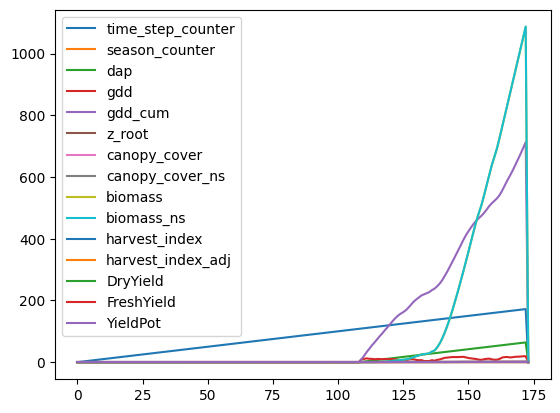

In [6]:
hist_run.crop_growth.plot()

<Axes: >

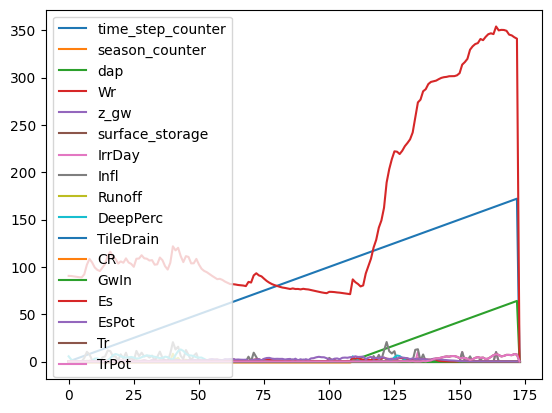

In [7]:
hist_run.water_flux.plot()

<Axes: >

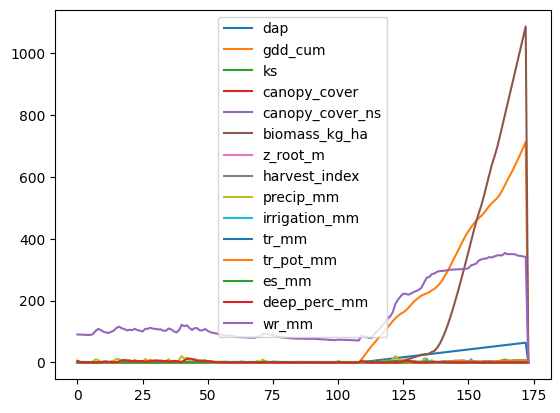

In [8]:
hist_run.daily_stress.plot()

In [9]:
hist_run.daily_stress

,dap,gdd_cum,ks,canopy_cover,canopy_cover_ns,biomass_kg_ha,z_root_m,harvest_index,precip_mm,irrigation_mm,tr_mm,tr_pot_mm,es_mm,deep_perc_mm,wr_mm
0,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.198555,0.0,0.000000,0.000000,0.247422,5.492395e+00,90.46
1,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.110465,0.0,0.000000,0.000000,0.246428,2.038999e+00,90.32
2,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.004844,0.0,0.000000,0.000000,0.423116,7.611475e-01,89.90
3,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000805,0.0,0.000000,0.000000,0.503559,2.847124e-01,89.40
4,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.323863,1.065797e-01,89.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,61.0,656.283802,1.0,0.953999,0.953999,978.647925,1.533940,0.0,0.047490,0.0,6.983016,6.983016,0.048407,1.443438e-13,345.31
170,62.0,674.436151,1.0,0.954903,0.954903,1014.475836,1.551464,0.0,0.000429,0.0,6.691615,6.691615,0.003318,0.000000e+00,344.48
171,63.0,693.612182,1.0,0.955670,0.955670,1050.222307,1.568920,0.0,0.062304,0.0,7.836080,7.836080,0.062469,0.000000e+00,342.52
172,64.0,712.786016,1.0,0.956322,0.956322,1085.884522,1.586309,0.0,0.000852,0.0,7.370585,7.370585,0.003677,0.000000e+00,341.02


In [10]:
hist_run.final_results

,Season,crop Type,Harvest Date (YYYY/MM/DD),Harvest Date (Step),Dry yield (tonne/ha),Fresh yield (tonne/ha),Yield potential (tonne/ha),Seasonal irrigation (mm)


---
## Block 5a — Operational forecast with AquaCrop

With AquaCrop, forecasting means rerunning the full simulation from Jan 1
with different future forcings appended. This preserves the stress-growth
coupling — a crop that was stressed in June will have smaller canopy in
July, which reduces water demand.

- **AROME** (0-48h): one AquaCrop run with deterministic forecast appended
- **IFS ENS** (0-15d): 50 AquaCrop runs, one per ensemble member
- **Blended report**: AROME days 0-2 (high resolution), IFS ENS days 3+ (ensemble spread)

In [6]:
# --- Cell: Extract current state from historical AquaCrop run ---
# (put this right after Block 3-4)

from irrigator.water_balance.aquacrop_adapter import (
    aquacrop_to_current_state,
    build_blended_stress_report,
    run_ensemble_aquacrop,
)

current_state = aquacrop_to_current_state(hist_run, soil, LAST_ERA5_DAY)

print(f"Current state at {LAST_ERA5_DAY}:")
print(f"  Depletion:  {current_state.depletion:.0f} mm")
print(f"  TAW:        {current_state.taw:.0f} mm")
print(f"  RAW:        {current_state.raw:.0f} mm")
print(f"  Ks:         {current_state.stress_coeff:.3f}")
print(f"  Root depth: {current_state.z_root:.2f} m")
print(f"  GDD:        {current_state.gdd:.0f}")
print(f"  Stage:      {current_state.crop_stage}")


Current state at 2026-06-23:
  Depletion:  137 mm
  TAW:        216 mm
  RAW:        98 mm
  Ks:         1.000
  Root depth: 1.59 m
  GDD:        713
  Stage:      midseason


In [7]:
# --- Cell: Build historical forcing for forecast branching ---

from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from datetime import timedelta
import numpy as np

# ERA5-Land historical
era5_last = pd.Timestamp(era5_daily.valid_time.values[-1]).date()
era5_forcing = forcing.slice(SIMULATION_START, era5_last)

# AROME gap fill (era5_last → yesterday)
gap_start = era5_last + timedelta(days=1)
gap_end = TODAY - timedelta(days=1)

if gap_start <= gap_end:
    arome_gap = load_arome_daily_cache(gap_start, gap_end, mode="static")
    gap_forcing = extract_parcel_forcing(arome_gap, parcel, terrain)
    historical_forcing = era5_forcing.concat(gap_forcing)
    print(f"Gap filled: {gap_forcing.n_days} days ({gap_start} → {gap_end})")
else:
    historical_forcing = era5_forcing
    print("No gap to fill")

print(f"Historical forcing: {historical_forcing.n_days} days")

fake_date = [
    np.datetime64(date(2026, 6, 24), "ns"),
    np.datetime64(date(2026, 6, 25), "ns"),
    np.datetime64(date(2026, 6, 26), "ns"),
]
fake_t_min = [20, 20, 20]
fake_t_max = [30, 30, 30]
fake_t_mean = [25, 25, 25]
fake_dewpoint = [14, 14, 14]
fake_windspeed = [3, 3, 3]
fake_press = [101, 101, 101]
fake_rs = [10, 10, 10]
fake_precip = [0, 0, 0]
historical_forcing.dates = np.insert(historical_forcing.dates, 174, fake_date)
historical_forcing.dewpoint = np.insert(historical_forcing.dewpoint, 174, fake_dewpoint)
historical_forcing.t_max = np.insert(historical_forcing.t_max, 174, fake_t_max)
historical_forcing.t_mean = np.insert(historical_forcing.t_mean, 174, fake_t_mean)
historical_forcing.t_min = np.insert(historical_forcing.t_min, 174, fake_t_min)
historical_forcing.precip_mm = np.insert(historical_forcing.precip_mm, 174, fake_precip)
historical_forcing.pressure_kpa = np.insert(historical_forcing.pressure_kpa, 174, fake_press)
historical_forcing.wind_speed_2m = np.insert(historical_forcing.wind_speed_2m, 174, fake_windspeed)
historical_forcing.rs_mj = np.insert(historical_forcing.rs_mj, 174, fake_rs)


19:19:42 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 6 days from ERA5-Land at grid cell (0, 45)
19:19:42 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:42 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 6 days, T=[16.0, 38.1]°C, total precip=1 mm, mean Rs=26.7 MJ/m²/day


Gap filled: 6 days (2026-06-24 → 2026-07-02)
Historical forcing: 180 days


In [8]:
# --- Cell: AROME 48h deterministic forecast ---

arome_today = load_arome_daily_cache(TODAY , TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_parcel_forcing(arome_today, parcel, terrain)
# Fix date alignment if needed
arome_forcing_48h.dates = arome_forcing_48h.dates - np.timedelta64(1, "D")

print(f"AROME forecast: {arome_forcing_48h.n_days} days")
print(f"  T range: [{arome_forcing_48h.t_min.min():.1f}, {arome_forcing_48h.t_max.max():.1f}] °C")

# Run full AquaCrop: historical + AROME 48h
arome_full_forcing = historical_forcing.concat(arome_forcing_48h)





arome_run = run_aquacrop(
    forcing=arome_full_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=pd.Timestamp(arome_full_forcing.dates[-2]).date(),
)

# Quick check: AROME Ks for the forecast days
arome_stress = arome_run.daily_stress
print(f"AROME last 3 days Ks: {arome_stress.ks.iloc[-4:-1].values}")


19:19:42 [arome] WARNING: 1 missing days: [datetime.date(2026, 7, 4)]
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 2 days from ERA5-Land at grid cell (0, 45)
19:19:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 2 days, T=[18.5, 35.9]°C, total precip=0 mm, mean Rs=26.6 MJ/m²/day
19:19:43 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.294-0.330, WP range 0.146-0.170, Ksat range 277-662 mm/day
19:19:43 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-02 (183 days), GDD=869, CC=0.96, biomass=1385 kg/ha


AROME forecast: 2 days
  T range: [18.5, 35.9] °C
AROME last 3 days Ks: [1.         0.9007356  0.85686619]


In [9]:
arome_stress

,dap,gdd_cum,ks,canopy_cover,canopy_cover_ns,biomass_kg_ha,z_root_m,harvest_index,precip_mm,irrigation_mm,tr_mm,tr_pot_mm,es_mm,deep_perc_mm,wr_mm
0,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.198555,0.0,0.000000,0.000000,0.247422,5.492395,90.46
1,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110465,0.0,0.000000,0.000000,0.246428,2.038999,90.32
2,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004844,0.0,0.000000,0.000000,0.423116,0.761147,89.90
3,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000805,0.0,0.000000,0.000000,0.503559,0.284712,89.40
4,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.323863,0.106580,89.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,70.0,820.024191,0.916679,0.955588,0.955588,1288.842950,1.689232,0.014497,0.074219,0.0,5.651097,6.164748,0.053179,0.000000,345.52
179,71.0,837.161984,1.000000,0.958826,0.958826,1323.866103,1.706159,0.016394,10.000000,10.0,5.494710,5.494710,0.034870,0.000000,355.87
180,72.0,853.687151,0.900736,0.957880,0.958826,1355.273501,1.723057,0.018528,0.000000,0.0,6.008914,6.671119,0.046951,0.000000,352.74
181,73.0,869.298368,0.856866,0.956450,0.958826,1384.994907,1.739864,0.020927,0.000000,0.0,5.566093,6.495872,0.052518,0.000000,352.99


In [10]:
# --- Cell: IFS ENS ensemble ---

from irrigator.ingestion.ifs_ens_client import load_ifs_daily

ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

# Extract per-member forcing at parcel level
member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    forcing_m = extract_parcel_forcing(member_ds, parcel, terrain)
    # Filter to remove arome overlap + limit due to shift utc + 1
    member_forcings[int(m)] = forcing_m.slice(start=TODAY + timedelta(2), end=TODAY + timedelta(14)) # hsould be 14

print(
    f"IFS ENS: {len(member_forcings)} members, {member_forcings[next(iter(member_forcings))].n_days} days"
)

# Run AquaCrop for each member (full simulation: Jan 1 → forecast end)
# Each member gets historical + its own forecast forcing
ensemble_stats = run_ensemble_aquacrop(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY - timedelta(days=1),
)

print(f"Ensemble stats: {len(ensemble_stats)} days")
for s in ensemble_stats[:3]:
    print(
        f"  Day {s.day_offset}: Ks={s.ks_mean:.3f} (p25={s.ks_p25:.3f}, p75={s.ks_p75:.3f}), "
        f"stress={s.n_members_stressed}/{s.n_members_total}"
    )


19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
19:19:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 16 days, T=[18.8, 36.3]°C, total precip=4 mm, mean Rs=26.0 MJ/m²/day
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
19:19:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 forcing: 16 days, T=[19.0, 35.6]°C, total precip=30 mm, mean Rs=25.4 MJ/m²/day
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
19:19:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-21 m, ΔT=0.13°C
19:19:43 [irrigator.atmospheric.forcing] INFO: Parcel 24_bergerac_001 for

IFS ENS: 50 members, 13 days


19:19:52 [irrigator.water_balance.aquacrop_adapter] INFO: Ensemble complete: 13 days, 50 members, stress_days=13


Ensemble stats: 13 days
  Day 0: Ks=0.677 (p25=0.670, p75=0.685), stress=50/50
  Day 1: Ks=0.635 (p25=0.626, p75=0.644), stress=50/50
  Day 2: Ks=0.600 (p25=0.587, p75=0.611), stress=50/50


In [11]:
# --- Cell: Blend AROME + IFS ENS into stress report ---

stress_report = build_blended_stress_report(
    arome_run=arome_run,
    ensemble_stats=ensemble_stats,
    today=TODAY,
    arome_days=2,
)

print(
    f"Blended report: {len(stress_report.daily_stats)} days "
    f"({stress_report.arome_days} AROME + {stress_report.ens_days} IFS ENS)"
)
for d in stress_report.daily_stats[:5]:
    print(
        f"  {d.date.date() if hasattr(d.date, 'date') else d.date}: "
        f"[{d.source}] Ks={d.ks_median:.3f}, stress_prob={d.stress_probability:.0%}"
    )


Blended report: 15 days (2 AROME + 13 IFS ENS)
  2026-07-03: [arome] Ks=0.901, stress_prob=0%
  2026-07-04: [arome] Ks=0.857, stress_prob=100%
  2026-07-05: [ifs_ens] Ks=0.676, stress_prob=100%
  2026-07-06: [ifs_ens] Ks=0.635, stress_prob=100%
  2026-07-07: [ifs_ens] Ks=0.597, stress_prob=100%


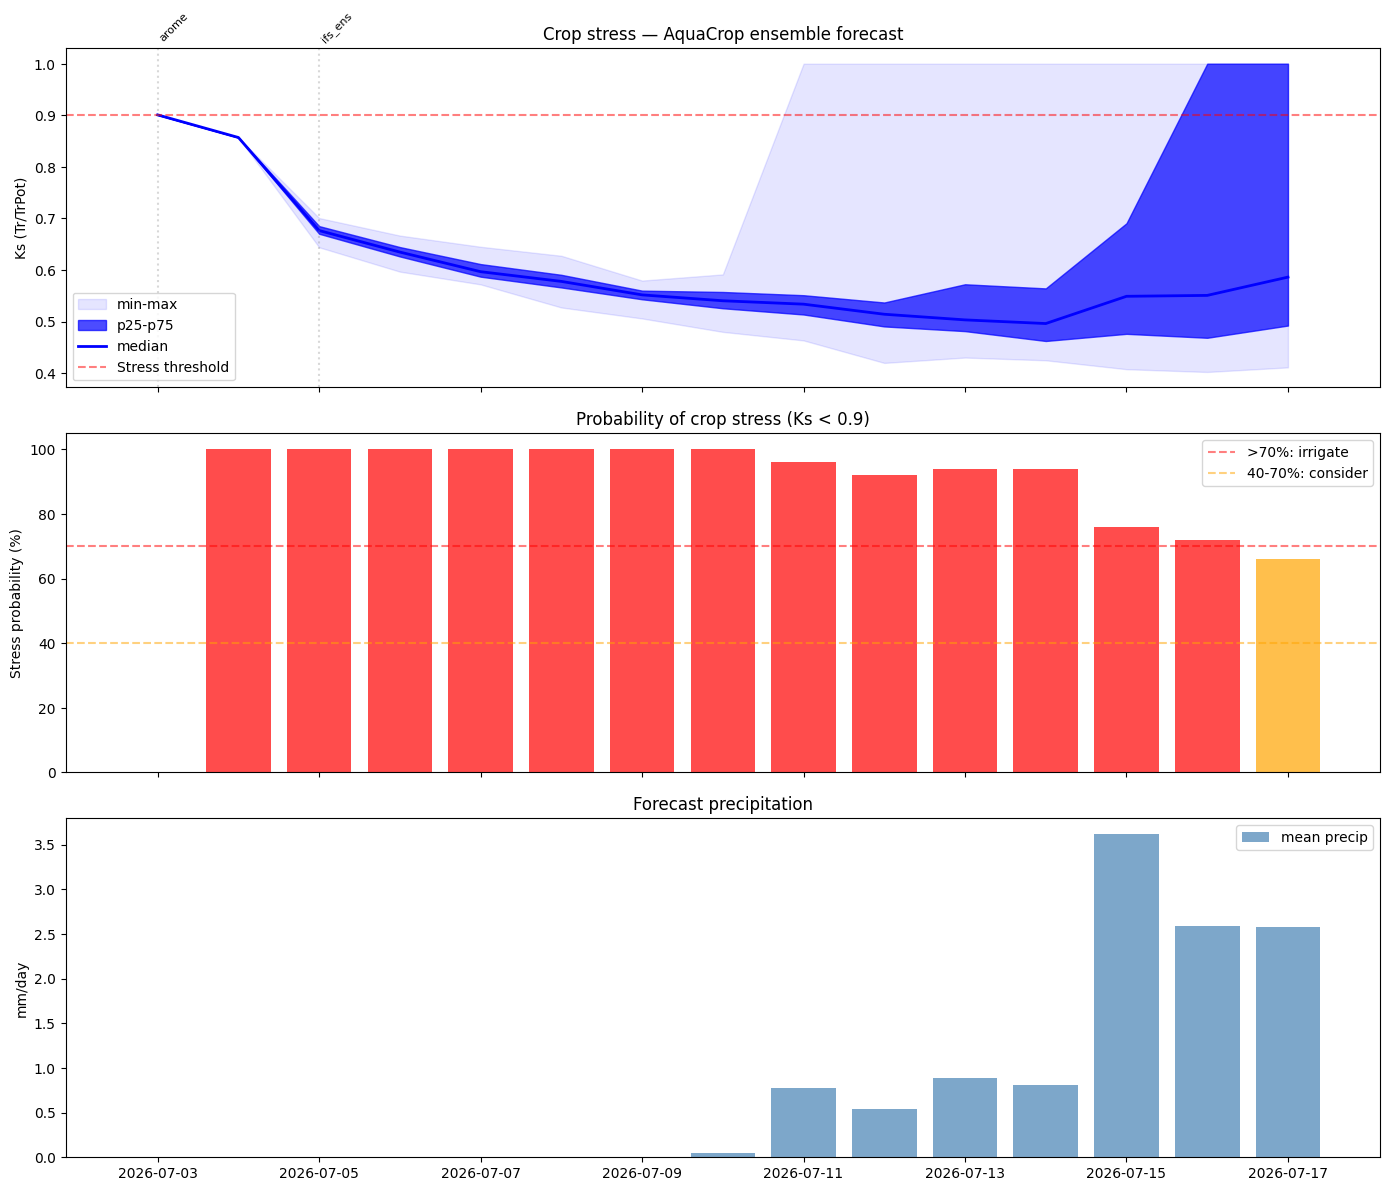

In [12]:
# --- Cell: Plot ensemble forecast (same as before, works unchanged) ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report.daily_stats]
sources = [d.source for d in stress_report.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report.daily_stats]
ks_min = [d.ks_min for d in stress_report.daily_stats]
ks_max = [d.ks_max for d in stress_report.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.7, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i - 1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks (Tr/TrPot)")
ax.set_title("Crop stress — AquaCrop ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.stress_probability for d in stress_report.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean precip")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()


---
## Block 5b — Seasonal Outlook (SEAS5, optional)

PCA analog matching → daily disaggregation → ensemble water balance.
Set `RUN_SEAS5 = True` at the top to enable.

In [17]:
outlook = None

if RUN_SEAS5:
    from irrigator.ingestion.cds_client import fetch_seas5, open_seas5
    from irrigator.forecasts.seas5_processor import (
        build_era5_monthly_climatology,
        correct_seas5_monthly,
    )
    from irrigator.forecasts.disaggregation import generate_seasonal_scenarios
    from irrigator.decision.seasonal_outlook import compute_seasonal_outlook

    init_year = TODAY.year
    init_month = TODAY.month

    # Fetch + bias correct SEAS5
    fetch_seas5(year=init_year, month=init_month, raw_dir=RAW_DIR)
    seas5_anom = open_seas5(raw_dir=RAW_DIR, year=init_year, month=init_month)
    era5_clim = build_era5_monthly_climatology(
        start_year=1993, end_year=2016, processed_dir=PROCESSED_DIR,
    )
    seas5_corrected = correct_seas5_monthly(seas5_anom, era5_clim, init_month=init_month)

    # Analog disaggregation (PCA + Mahalanobis + spatial voting)
    scenarios = generate_seasonal_scenarios(
        cfg=cfg,
        era5_daily=era5_daily,
        seas5_corrected=seas5_corrected,
        init_month=init_month,
        n_leads=4,
    )

    # Run water balance under each scenario
    outlook = compute_seasonal_outlook(
        scenarios=scenarios,
        parcel=parcel,
        terrain=terrain,
        soil=soil,
        crop_params=crop_params,
    )

    print(f"\nSeasonal outlook ({outlook.n_members} members):")
    print(f"  Irrigation needed: {outlook.total_irrigation_p25:.0f}–{outlook.total_irrigation_p75:.0f} mm (p25–p75)")
    print(f"  Median: {outlook.total_irrigation_median:.0f} mm")
    print(f"  Stress days: median {outlook.stress_days_median:.0f}")
    print(f"  {outlook.season_description}")
else:
    print("SEAS5 seasonal outlook skipped (set RUN_SEAS5=True to enable)")

SEAS5 seasonal outlook skipped (set RUN_SEAS5=True to enable)


---
## Block 6 — Irrigation Decision

Uses current_state (from AquaCrop) + stress_report (blended AROME + IFS ENS)
to produce an actionable recommendation. The decision logic is unchanged —
it works with the EnsembleStressReport format regardless of whether the
underlying model is FAO-56 bucket or AquaCrop.

In [13]:
from irrigator.decision.rules import compute_recommendation, DecisionParams
from irrigator.decision.output import build_parcel_report, save_report, format_sms
from irrigator.crop.phenology import CropParams

crop_params = CropParams.from_config(parcel.crop, crop_params_path=CROP_PARAMS_PATH)

params = DecisionParams.from_config(
    model_params_path=MODEL_PARAMS_PATH,
    parcel=parcel,
)

advice = compute_recommendation(
    current_state=current_state,
    stress_report=stress_report,
    crop_params=crop_params,
    params=params,
    last_irrigation_date=LAST_IRRIGATION,
)

print(f"\n{'=' * 60}")
print(f"IRRIGATION RECOMMENDATION for {parcel.name}")
print(f"{'=' * 60}")
action = "Irrigate" if advice.irrigate else "No need to irrigate"
print(f"  Action:     {action}")
if advice.dose_mm:
    print(f"  Amount:     {advice.dose_mm:.0f} mm")
print(f"  Confidence: {advice.confidence}")
print(f"  Reason:     {advice.reason}")
print(f"  Stage:      {advice.crop_stage}")
if advice.stress_probability is not None:
    print(f"  Stress probability: {advice.stress_probability:.0%}")
print(f"{'=' * 60}")



IRRIGATION RECOMMENDATION for Parcelle Les Graves
  Action:     Irrigate
  Amount:     50 mm
  Confidence: high
  Reason:     100% of ensemble members show stress. Depletion 137/216 mm. Forecast rain: 6 mm. Recommend 50 mm on 2026-06-23
  Stage:      midseason
  Stress probability: 100%


In [22]:
# Build and save JSON report
print(f"\nSMS: {format_sms(advice)}")



SMS: [IrriGator] 2026-06-23: IRRIGUER 63mm le 2026-06-23. Réserve sol: 59%. Stade: midseason.


---
## Block 6b — Ensemble Irrigation Optimizer

Instead of simple threshold rules, tests candidate irrigation actions
against each IFS ENS member and picks the best action by ensemble consensus.

Tests: no irrigation, plus each (day, dose) combination:
- Days: 0, 1, 2, ..., 7 days from today
- Doses: min (15mm), mid (27mm), max (40mm) from parcel config

For 25 candidates × 50 members = ~1250 AquaCrop runs (~5-8 minutes).

In [13]:
# --- Cell: Run optimizer ---

from irrigator.water_balance.aquacrop_adapter import (
    evaluate_candidates_ensemble,
    recommend_from_optimizer,
    build_candidates,
    evaluate_candidates_ensemble_branching_2level
)

# Build candidate actions from parcel constraints
candidates = build_candidates(parcel, max_days_ahead=15, max_events=3)
print(f"Testing {len(candidates)} candidates × {len(member_forcings)} members")
print(f"Candidates: {[c.label for c in candidates[:5]]}...")

# Evaluate each candidate against the ensemble
# This is the expensive step (~5-8 minutes)

optimizer_results = evaluate_candidates_ensemble_branching_2level(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY,
    candidates=candidates,
    workers=10,
    stress_threshold=0.9,
    arome_days=2,
)


19:19:52 [irrigator.water_balance.aquacrop_adapter] INFO: Built 395 candidates (1-event: 48, 2-event: 182, 3-event: 164)


19:19:53 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.294-0.330, WP range 0.146-0.170, Ksat range 277-662 mm/day


Testing 395 candidates × 50 members
Candidates: ['No irrigation', '15mm on day+0', '32mm on day+0', '50mm on day+0', '15mm on day+1']...


19:19:56 [irrigator.water_balance.aquacrop_adapter] INFO: Evaluating 395 candidates × 50 members = 19750 AquaCrop branches (two-level branching, arome_days=2, workers=10)
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 1/395 'No irrigation': mean_stress=0.523, avoid_pct=0%, mean_stress_days=11.9
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 2/395 '15mm on day+0': mean_stress=0.463, avoid_pct=0%, mean_stress_days=10.9
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 3/395 '32mm on day+0': mean_stress=0.383, avoid_pct=0%, mean_stress_days=7.9
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 4/395 '50mm on day+0': mean_stress=0.256, avoid_pct=4%, mean_stress_days=5.3
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 5/395 '15mm on day+1': mean_stress=0.461, avoid_pct=0%, mean_stress_days=9.9
19:21:02 [irrigator.water_balance.aquacrop_adapter] INFO: Candidate 6/395 '32mm on day+1': mean_stress

In [18]:
# --- Cell: Optimizer recommendation ---

recommendation = recommend_from_optimizer(optimizer_results, top_x=3)

print(f"\n{'=' * 60}")
print(f"OPTIMIZED IRRIGATION RECOMMENDATION")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[0]['action']}")
print(f"  Reason:     {recommendation[0]['reason']}")
print(f"  Avoid stress: {recommendation[0]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[0]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[0]:
    print(f"  Water cost: €{recommendation[0]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")


print(f"\n{'=' * 60}")
print(f"ALTERNATIVES")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[1]['action']}")
print(f"  Reason:     {recommendation[1]['reason']}")
print(f"  Avoid stress: {recommendation[1]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[1]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[1]:
    print(f"  Water cost: €{recommendation[1]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[2]['action']}")
print(f"  Reason:     {recommendation[2]['reason']}")
print(f"  Avoid stress: {recommendation[2]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[2]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[2]:
    print(f"  Water cost: €{recommendation[2]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")


OPTIMIZED IRRIGATION RECOMMENDATION
  Action:     2×50mm on day+0 & +3
  Reason:     100% of members avoid stress. Mean stress days: 0.0 vs 11.9 without irrigation
  Avoid stress: 100% of members
  Mean stress days: 0.0
  Water cost: €250/ha

ALTERNATIVES
  Action:     2×50mm on day+0 & +4
  Reason:     100% of members avoid stress. Mean stress days: 0.0 vs 11.9 without irrigation
  Avoid stress: 100% of members
  Mean stress days: 0.0
  Water cost: €250/ha
  Action:     2×50mm on day+0 & +5
  Reason:     100% of members avoid stress. Mean stress days: 0.0 vs 11.9 without irrigation
  Avoid stress: 100% of members
  Mean stress days: 0.0
  Water cost: €250/ha


In [16]:
recommendation

[{'action': '2×50mm on day+0 & +3',
  'reason': '100% of members avoid stress. Mean stress days: 0.0 vs 11.9 without irrigation',
  'candidate': IrrigationCandidate(events=[(0, 50), (3, 50)], label='2×50mm on day+0 & +3'),
  'avoid_stress_pct': 1.0,
  'mean_stress_days': 0.0,
  'cost_eur_ha': 250.0,
  'all_results': [CandidateResult(candidate=IrrigationCandidate(events=[(1, 50), (5, 50), (11, 50)], label='3×50mm on day+1,5,11'), member_max_stress=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1102230246251565e-16, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1102230246251565e-16, 0.0, 1.1102230246251565e-16, 0.0, 0.0, 0.0, 0.0, 1.1102230246251565e-16, 0.0, 1.1102230246251565e-16, 1.1102230246251565e-16, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1102230246251565e-16, 0.0, 0.0, 0.0, 0.0, 0.0], member_stress_days=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

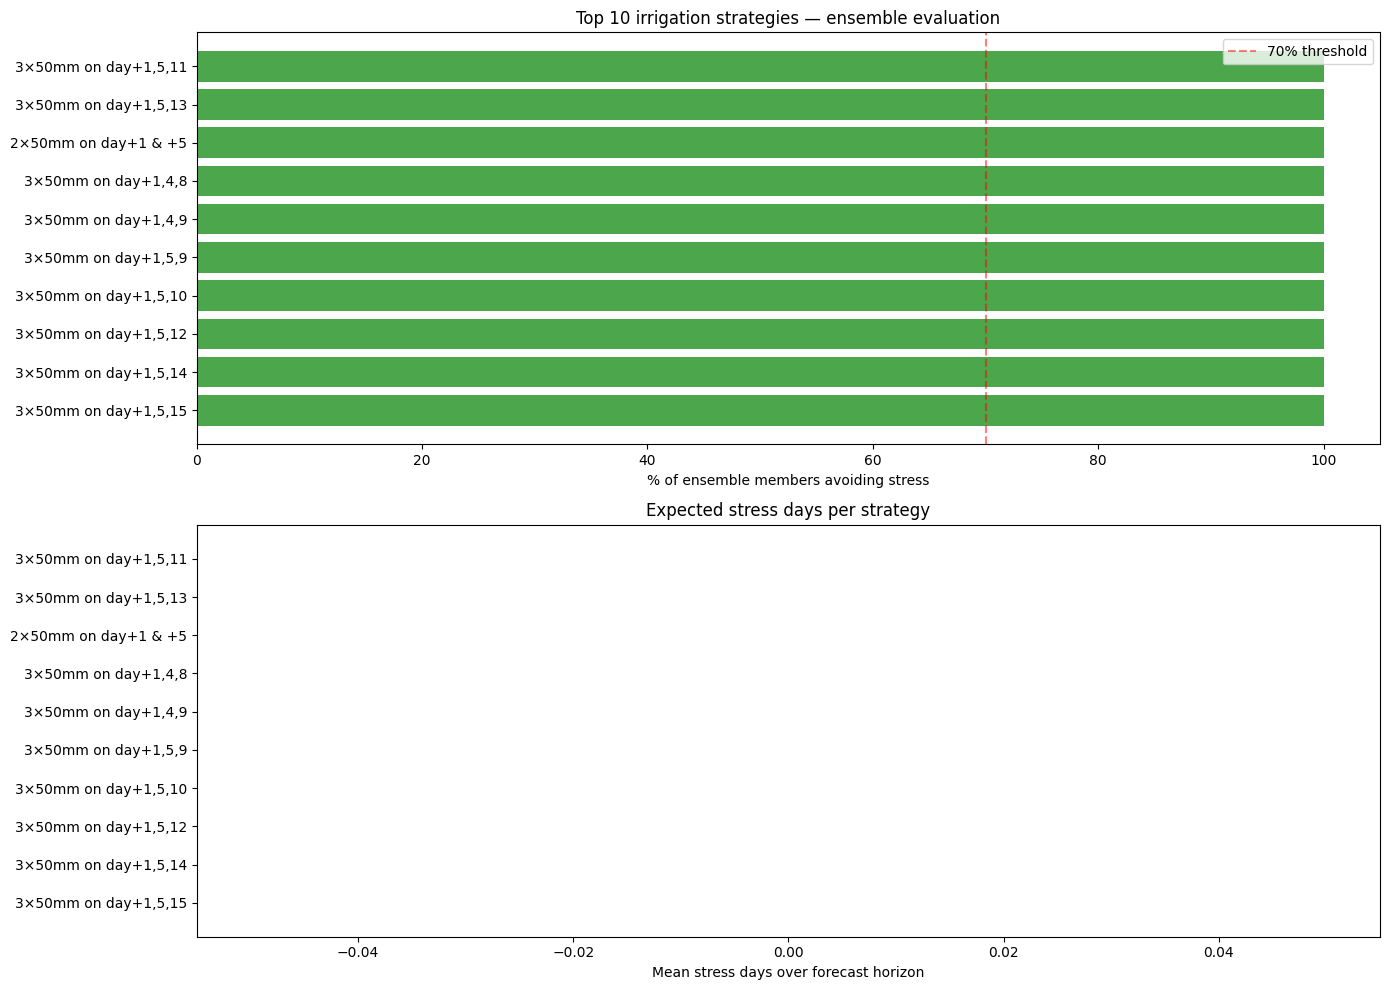

In [ ]:
# --- Cell: Plot optimizer comparison ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 10 candidates by avoid_stress_pct
top10 = optimizer_results[:10]

labels = [r.candidate.label for r in top10]
avoid_pct = [r.pct_members_avoid_stress * 100 for r in top10]
mean_stress = [r.mean_stress_days for r in top10]

ax = axes[0]
colors = ["green" if p > 70 else "orange" if p > 40 else "red" for p in avoid_pct]
bars = ax.barh(range(len(top10)), avoid_pct, color=colors, alpha=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels)
ax.axvline(70, color="red", ls="--", alpha=0.5, label="70% threshold")
ax.set_xlabel("% of ensemble members avoiding stress")
ax.set_title("Top 10 irrigation strategies — ensemble evaluation")
ax.legend()
ax.invert_yaxis()

ax = axes[1]
ax.barh(range(len(top10)), mean_stress, color="steelblue", alpha=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels)
ax.set_xlabel("Mean stress days over forecast horizon")
ax.set_title("Expected stress days per strategy")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [29]:
# --- Cell: Detailed comparison table ---

print(f"\n{'Label':<25} {'Avoid %':>8} {'Stress days':>12} {'Mean stress':>12}")
print("-" * 60)
for r in optimizer_results[:15]:
    print(
        f"{r.candidate.label:<25} {r.pct_members_avoid_stress:>7.0%} "
        f"{r.mean_stress_days:>11.1f} {r.mean_max_stress:>11.3f}"
    )



Label                      Avoid %  Stress days  Mean stress
------------------------------------------------------------
2×50mm on day+1 & +5         100%         0.0       0.000
2×50mm on day+1 & +4         100%         0.0       0.000
2×50mm on day+0 & +3         100%         0.0       0.000
2×50mm on day+0 & +4         100%         0.0       0.000
2×50mm on day+0 & +5         100%         0.0       0.007
2×50mm on day+1 & +6         100%         0.0       0.008
2×50mm on day+0 & +6          96%         0.0       0.043
2×50mm on day+1 & +7          80%         0.2       0.067
2×50mm on day+0 & +7          64%         0.4       0.089
2×50mm on day+1 & +8          52%         0.7       0.105
2×50mm on day+0 & +8          30%         1.1       0.125
2×50mm on day+1 & +9          24%         1.4       0.148
2×50mm on day+1 & +10         20%         2.2       0.175
2×50mm on day+1 & +11         16%         2.9       0.197
2×50mm on day+0 & +9          12%         1.9       0.160


---
## Summary: data flow

```
ERA5-Land France-wide cache ──[Block 2: extract + downscale]──→ DailyForcing (parcel)
                                                                       │
                                                      [Blocks 3+4: simulation]──→ current_state
                                                                                        │
AROME France-wide cache ──[extract + downscale]──→ DailyForcing (parcel)                │
                                                         │                              │
IFS ENS download ──[process daily]──[extract]──→ 51× DailyForcing (parcel)              │
                                                         │                              │
                                              [Block 5a: ensemble forward balance]──────┤
                                                                                        │
SEAS5 ──[bias correct]──[PCA analog]──[extract]──→ N× DailyForcing                     │
                                                         │                              │
                                              [Block 5b: seasonal water balance]────────┤
                                                                                        │
                                              [Block 6: decision rules]─────→ IrrigationAdvice
```

All gridded data sources (ERA5-Land, AROME, IFS ENS, SEAS5 analogs) are France-wide.
Parcel extraction happens once through `extract_parcel_forcing()` — one function,
one set of corrections (lapse rate, radiation, wind), for all sources.